Importing Dependencies

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# Load Data
df_ethiopia = pd.read_csv('../data/ethiopia_clean.csv')
df_kenya = pd.read_csv('../data/kenya_clean.csv')
df_nigeria = pd.read_csv('../data/nigeria_clean.csv')
df_sudan = pd.read_csv('../data/sudan_clean.csv')
df_tanzania = pd.read_csv('../data/tanzania_clean.csv')

In [4]:
#Concatenate Data Frame
df_all = pd.concat([df_tanzania,df_ethiopia, df_kenya, df_nigeria, df_sudan], axis=0)
df_all.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,date,month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


In [5]:
#Numeric columns describe
df_all[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']].describe()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
count,19881.000000,19881.000000,19881.000000,19881.000000,19881.000000,19881.000000,19881.000000
mean,23.777334,29.253226,19.269265,2.194183,65.327046,2.981626,4.251572
std,5.367638,5.138066,6.516785,3.971074,21.965436,1.162123,1.390426
min,10.420000,15.650000,2.460000,0.000000,4.690000,0.460000,0.790000
25%,19.510000,26.770000,13.510000,0.010000,55.680000,2.090000,3.160000
50%,25.230000,28.760000,22.050000,0.380000,72.500000,2.830000,4.200000
75%,27.560000,30.760000,25.270000,2.470000,82.330000,3.810000,5.240000
max,37.990000,45.960000,32.170000,26.960000,93.610000,7.260000,8.790000


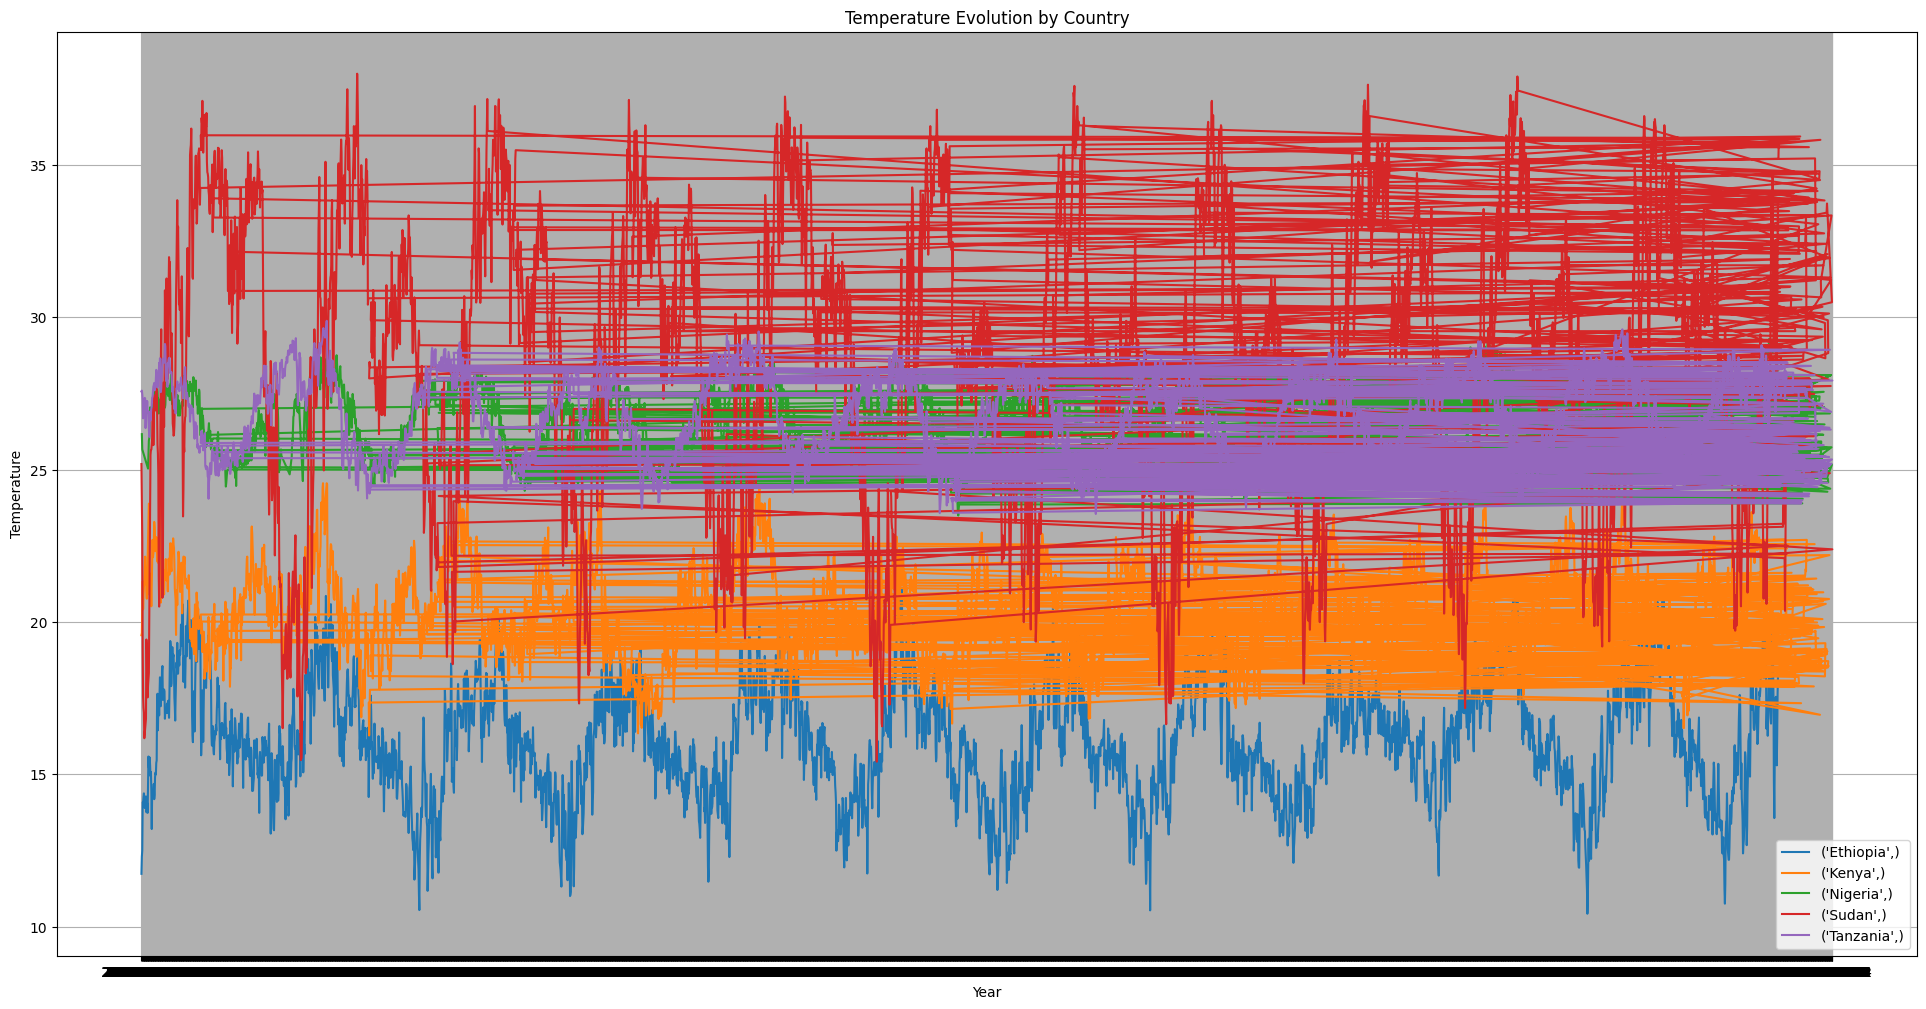

In [6]:
# Group the data by continent and calculate the average life expectancy for each year
df_country = df_all.groupby(['country'])

# Create a figure and axis object using the object-oriented approach
fig, ax = plt.subplots(figsize=(24, 12))

# Plot each group as a separate line
for key, group in df_country:
    ax.plot(group['date'], group['T2M'], label=key)

# Set axis labels and title
ax.set_xlabel('Year')
ax.set_ylabel('Temperature')
ax.set_title('Temperature Evolution by Country')

# Add a legend
ax.legend()

# Display the grid
ax.grid(True)

# Show the plot
plt.show()

In [7]:
# Sumaary table comparing mean, median, standard deviation
df_stats_country = df_all.groupby('country')['T2M'].agg(['mean', 'median', 'std'])
print(df_stats_country)

               mean  median       std
country                              
Ethiopia  16.096771   16.06  1.882141
Kenya     20.450133   20.39  1.421248
Nigeria   26.735115   26.91  1.068903
Sudan     28.793320   29.23  4.691019
Tanzania  26.802536   27.00  1.327645


Precipitation Variablility Comparision

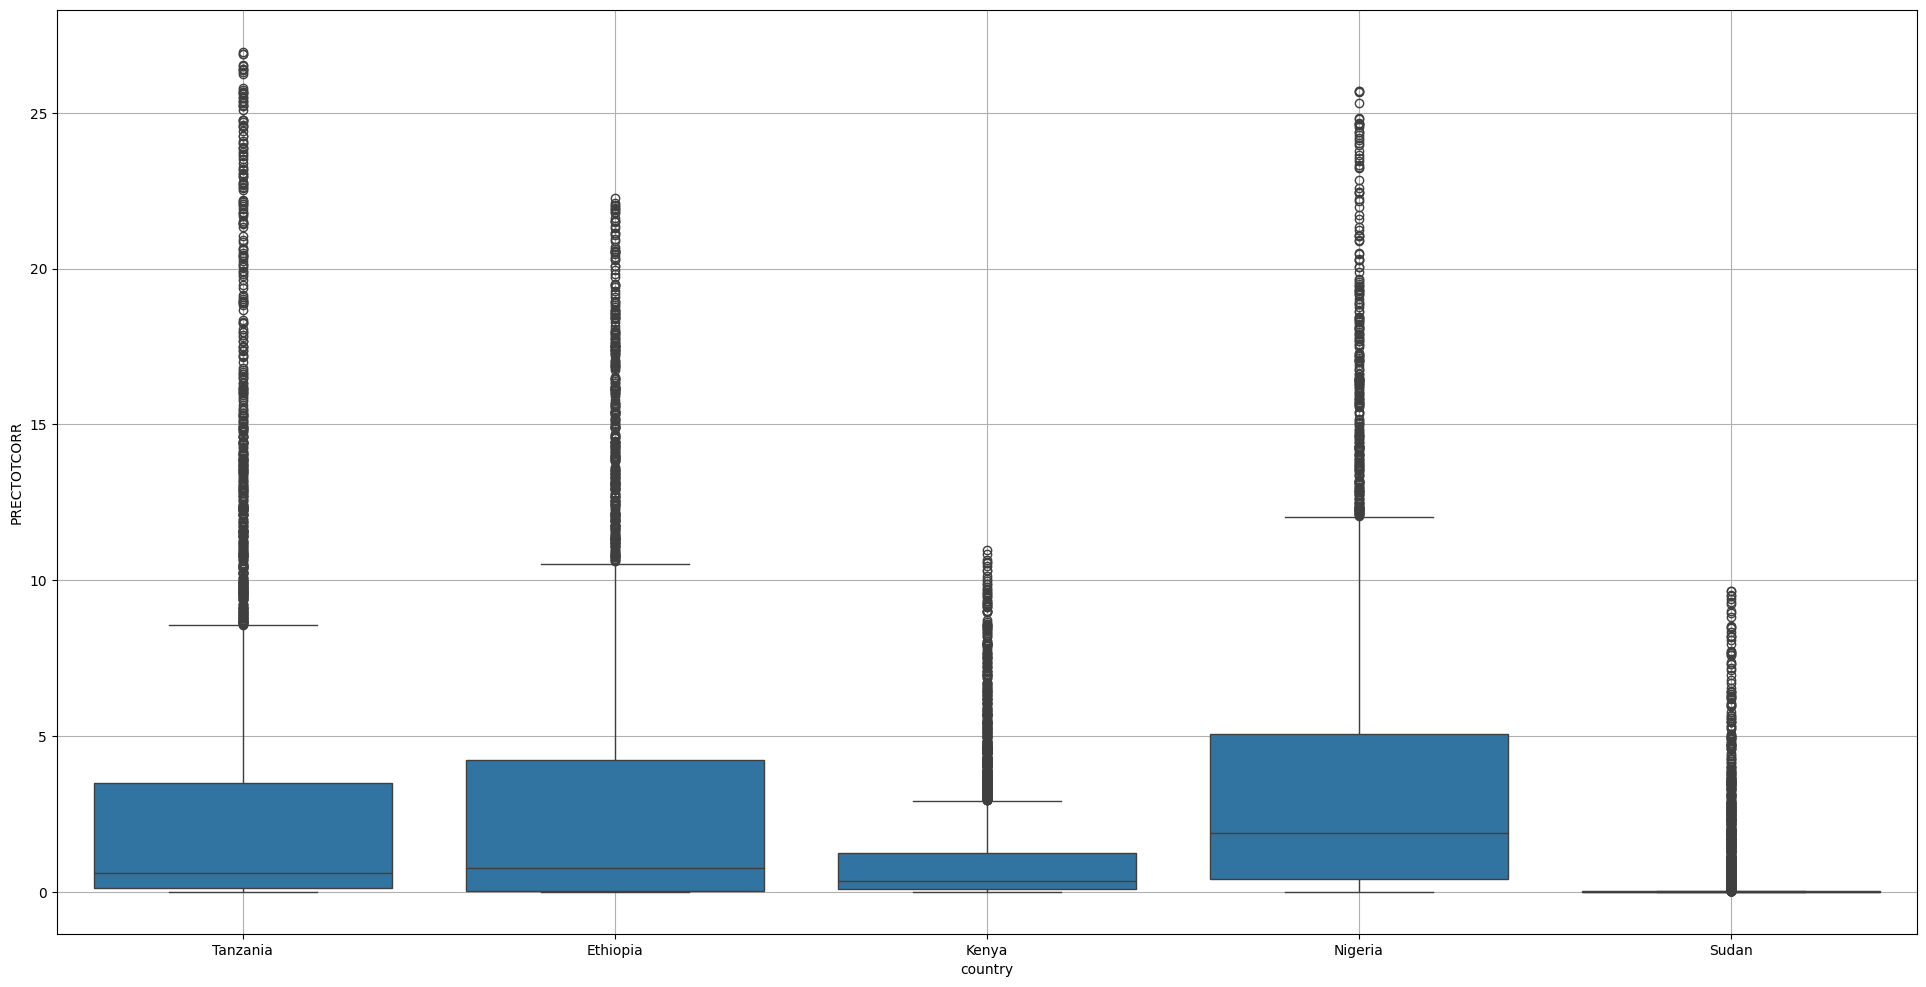

In [8]:
plt.figure(figsize=(24, 12))

sns.boxplot(data=df_all, x='country', y='PRECTOTCORR')

plt.grid(True)

plt.show()

In [9]:
# Sumaary table comparing mean, median, standard deviation
df_stats_country = df_all.groupby('country')['PRECTOTCORR'].agg(['mean', 'median', 'std'])
print(df_stats_country)

              mean  median       std
country                             
Ethiopia  3.016690    0.76  4.569478
Kenya     1.100035    0.36  1.763646
Nigeria   3.645836    1.88  4.600613
Sudan     0.321469    0.00  1.116769
Tanzania  2.939913    0.61  4.966938


Extreme Event Frequency

In [10]:
df_all.groupby('country').count()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,month
country,,,,,,,,,,,,,,
Ethiopia,3976,3976,3976,3976,3976,3976,3976,3976,3976,3976,3976,3976,3976,3976
Kenya,3987,3987,3987,3987,3987,3987,3987,3987,3987,3987,3987,3987,3987,3987
Nigeria,3883,3883,3883,3883,3883,3883,3883,3883,3883,3883,3883,3883,3883,3883
Sudan,4024,4024,4024,4024,4024,4024,4024,4024,4024,4024,4024,4024,4024,4024
Tanzania,4011,4011,4011,4011,4011,4011,4011,4011,4011,4011,4011,4011,4011,4011
